<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/Machine_learning-with-Shah/blob/main/Function_Transformer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
dataset = pd.read_excel("/content/ML_Dataset_200rows.xlsx", header=1)
dataset = dataset.iloc[1:].reset_index(drop=True)
display(dataset.head())

,Age,Experience_Yrs,Education,Department,Hours_Per_Week,Performance,Satisfaction,Salary_USD,High_Earner,Salary_Target
0,50,27,High School,HR,37,71.4,3.3,80369,1,80369
1,36,12,Bachelor,Finance,52,64.6,3.7,62589,1,62589
2,29,7,Bachelor,HR,44,57.6,3.3,43859,0,43859
3,42,21,Bachelor,Marketing,43,61.1,3.6,80405,1,80405
4,40,16,Master,Marketing,40,64.2,4.2,71879,1,71879


In [8]:
dataset.isnull().sum()

,0
Age,1
Experience_Yrs,2
Education,2
Department,2
Hours_Per_Week,2
Performance,10
Satisfaction,2
Salary_USD,12
High_Earner,2
Salary_Target,2


In [9]:
dataset.notnull().sum()

,0
Age,202
Experience_Yrs,201
Education,201
Department,201
Hours_Per_Week,201
Performance,193
Satisfaction,201
Salary_USD,191
High_Earner,201
Salary_Target,201


In [10]:
dataset.shape

(203, 10)

In [11]:
dataset.describe()

,Age,Experience_Yrs,Education,Department,Hours_Per_Week,Performance,Satisfaction,Salary_USD,High_Earner,Salary_Target
count,202,201,201,201,201,193.0,201.0,191,201,201
unique,40,40,5,6,26,155.0,29.0,187,3,199
top,45,9,Bachelor,Marketing,52,70.7,3.3,18000,1,18000
freq,10,11,81,48,14,4.0,16.0,3,149,3


In [15]:
dataset["Salary_USD"] = pd.to_numeric(dataset["Salary_USD"], errors='coerce')
dataset["Salary_USD"].fillna(dataset["Salary_USD"].mean(), inplace=True)

/tmp/ipykernel_7267/1058135593.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["Salary_USD"].fillna(dataset["Salary_USD"].mean(), inplace=True)


In [16]:
dataset.isnull().sum()

,0
Age,1
Experience_Yrs,2
Education,2
Department,2
Hours_Per_Week,2
Performance,10
Satisfaction,2
Salary_USD,0
High_Earner,2
Salary_Target,2


/tmp/ipykernel_7267/628920338.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Salary_USD"])


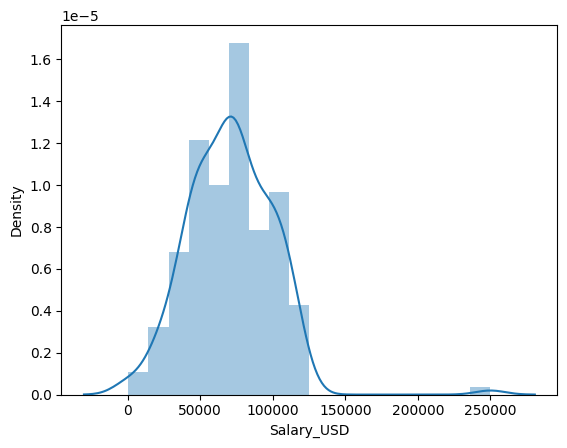

In [17]:
sns.distplot(dataset["Salary_USD"])
plt.show()

In [23]:
q1 = dataset["Salary_USD"].quantile(0.25)
q3 = dataset["Salary_USD"].quantile(0.75)
iqr = q3-q1

In [20]:
min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)
min_r,max_r

(np.float64(112143.5), np.float64(29467.5))

In [24]:
dataset = dataset[dataset["Salary_USD"]<max_r]

In [25]:
from sklearn.preprocessing import FunctionTransformer

In [26]:
ft= FunctionTransformer(func=np.log1p)

In [27]:
ft.fit(dataset[["Salary_USD"]])

FunctionTransformer(func=<ufunc 'log1p'>)

In [29]:
dataset["Salary_USD_ft"] = ft.transform(dataset[["Salary_USD"]])

/tmp/ipykernel_7267/2575415567.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Salary_USD"])
/tmp/ipykernel_7267/2575415567.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Salary_USD_ft"])


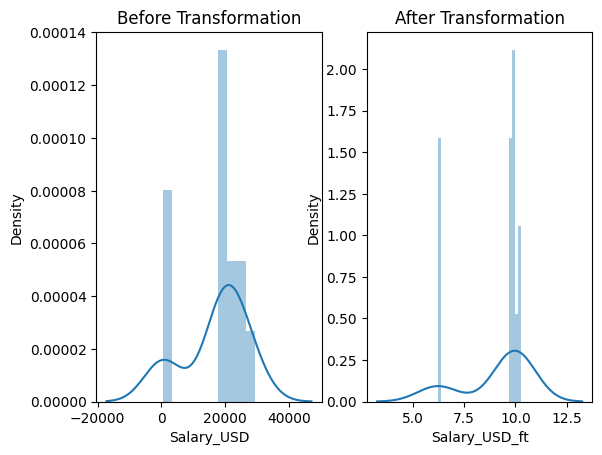

In [31]:
plt.subplot(1,2,1)
sns.distplot(dataset["Salary_USD"])
plt.title("Before Transformation")
plt.subplot(1,2,2)
sns.distplot(dataset["Salary_USD_ft"])
plt.title("After Transformation")
plt.show()

In [32]:
ft1 = FunctionTransformer(func=lambda x:x**2)

ft1.fit(dataset[["Salary_USD"]])

FunctionTransformer(func=<function <lambda> at 0x78f7e6cd0400>)

In [33]:
dataset["Salary_USD_ft1"]=ft1.transform(dataset[["Salary_USD"]])

/tmp/ipykernel_7267/3275199093.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Salary_USD"])
/tmp/ipykernel_7267/3275199093.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Salary_USD_ft1"])


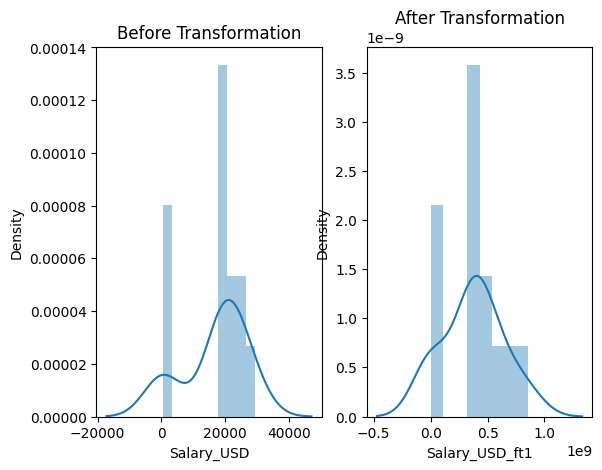

In [34]:
plt.subplot(1,2,1)
sns.distplot(dataset["Salary_USD"])
plt.title("Before Transformation")
plt.subplot(1,2,2)
sns.distplot(dataset["Salary_USD_ft1"])
plt.title("After Transformation")
plt.show()